# API Tutorial of Event Related Potentials (ERPs) Simulation

This example demonstrates how to simulate an event-related potential (ERP) using the HNN Python API.

The workflow below recreates examples of the tactile evoked response as observed in Jones et al., J. Neuroscience 2007 [1] and as detailed in the [ERP Tutorial]() on our [HNN Textbook Website](https://jonescompneurolab.github.io/textbook/content/preface.html)


In [3]:
# Authors:
#   Mainak Jas <mmjas@mgh.harvard.edu>
#   Sam Neymotin <samnemo@gmail.com>
#   Blake Caldwell <blake_caldwell@brown.edu>
#   Christopher Bailey <cjb@cfin.au.dk>
#   Dylan Daniels <dylan_s_daniels@alumni.brown.edu>

## Set Up Your HNN Environment

We assume for this walkthrough that you have access to the latest stable version of the `hnn-core` software. If not, please follow the instructions on our [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) to step up HNN. We also recommend reading the remainer of this page in full, as there are additional instructions for following along with the ERP walkthrough.

Note that the [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) includes instructions for running HNN "on the cloud" and for installing HNN locally on your personal machine. While the cloud versions of HNN can be relatively easy to get up and running, they do come with certain limitations (such as limited access to compute cores in the case of Google CoLab). As such, we recommend that you install HNN on your local machine using the `conda` installation method. However, if you are unable to install HNN locally, using one of the cloud methods is a perfectly viable alternative. 

The (recommended) `conda` installation method will install the latest **stable** version of `hnn-core` on your device, including the Graphical User Interface (GUI) and other dependencies for running faster simulations using parallelism (i.e., multuiple processor cores).

Once you have completed the `conda` installation instructions, you can activate your conda environment with the following Command Line command:

```bash
conda activate hnn-core-env
```

You can then launch the GUI from the active conda environment with the following command:

```bash
hnn-gui
```

### Following Along With the Textbook's Python API Tutorials


Note that any code blocks on the subsequent pages of the **Simulating ERPs** walkthrough are *cumulative*. That is to say, these code blocks are meant to be run in sequential order, as they are drawn from a single `ipython` notebook file. 

By clicking the `Download Notebook` button at the top of this page, you can download the entire `.ipynb` file and run it interactively through Jupyter Notebook or through your preferred code editor (VS Code, Pycharm, etc.).

Keep in mind that your code editor may install additional dependencies needed to open and run `.ipynb` files when using the `hnn-core-env` conda environment. 

If you would like to launch a Jupyter Notebook server directly from the Command Line, you will need to install Jupyter's `notebook` dependency directly into `hnn-core-env`. To do so, run the following command from your active `hnn-core-env` conda environment:

```bash
conda install -c conda-forge notebook
```

After installation, you can launch the jupyter server with the following command:

```bash
jupyter notebook
```

Alternatively, you can start an interactive ipython environment with the command below. This will allow you to run individual commands from your Command Line interface without needing to install the additional `notebook` dependency from Jupyter.  

```bash
ipython
```

### Accessing Data and Network Files

At various points in the tutorials, we will reference particular network and/or data files. These files can be found on our [hnn-data GitHub repository](https://github.com/jonescompneurolab/hnn-data/)

In brief, the `MEG_detection_data` subdirectory contains the experimental MEG data referenced in our Jones et al. (2007) study, while the `network-configurations` subdirectory contains various network configuration files for simulating ERPs and rhythms

We recommend that you clone this repository to your local machine, as you will need several of these files to follow along with the tutorials

You can clone this repository with the following command:

```bash
git clone https://github.com/jonescompneurolab/hnn-data.git
```

We will periodically update or add new network configuration files, so we recommend occasionally pulling the latest changes from GitHub. You can do so with the following commands:

```bash
git checkout main
git pull origin main
```


## Using the HNN Python API

### Import HNN and Instantiate a Model

Once you've set up your `hnn-core` environment, you are ready to use HNN's Python API. The very first thing you'll want to do (after activating your environment) is to import the `hnn_core` package

We'll also import one of the default models, `jones_2009_model`, which is the laminar SI model as originally presented in Jones et al., 2009.

In [4]:
import hnn_core  # noqa
from hnn_core import jones_2009_model

--No graphics will be displayed.


The HNN Python API is designed around the network object, which we will interact with to set parameters, run simulations, view simulation outputs, and more. 

We can create an instance of the default `jones_2009_model` by assigning it to a variable, such as net_default.

In [5]:
net_default = jones_2009_model()

### Interacting with the Network Object

We can then interact with the `network` object by using its available attributes

For example, the code block below will print the public-facing methods and data attributes that are available. For simplicity, we will only print the "public" attributes. There are additional "private" attributes that advanced users may want to interact with

In [6]:
# get all available attributes
attributes = dir(net_default)

# get the available *methods* (functions) that act on the network object
methods = [
    attr
    for attr in attributes
    # limit to attributes that *are* callable
    if callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# get the available *data attributes* that are associated with the
# network object
data_attributes = [
    attr
    for attr in attributes
    # limit to attributes that *are not* callable
    if not callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# print public methods
print("Methods:")
print(*methods, sep=", ")

# print public data attributes
print("\nData attributes:")
print(*data_attributes, sep=", ")

Methods:
add_bursty_drive, add_connection, add_electrode_array, add_evoked_drive, add_poisson_drive, add_spike_train_drive, add_tonic_bias, clear_connectivity, clear_drives, copy, filter_cell_types, get_global_synaptic_gains, gid_to_type, plot_cells, set_cell_positions, set_global_synaptic_gains, to_dict, write_configuration

Data attributes:
cell_response, cell_types, connectivity, delay, external_biases, external_drives, gid_ranges, pos_dict, rec_arrays, threshold


We can then use these attributes with the network object we instantiated previously

First, let's try examining one of the network's data attributes: `cell_types`. We can check the object's `type` so we know how to interact with it

In [7]:
# check the `net.cell_types` object's type
print(f"Object type: {type(net_default.cell_types)}")

Object type: <class 'dict'>


Now that we have confirmed the `net.cell_types` object is a dictionary, we know how to ineract with it using native Python code

Next, let's print the dictionary's keys, which in this case will tell us the unique cell types in the network

In [8]:
print("Cell types:")

# loop through the dictionary keys and print them
for key in net_default.cell_types.keys():
    print(f"\t{key}")

Cell types:
	L2_basket
	L2_pyramidal
	L5_basket
	L5_pyramidal


Let's examine one of these `cell_types` objects in more detail. We'll use "L5_pyramidal" as an example, and we'll assign it a variable for easier access

In [9]:
# assign net_default.cell_types["L5_pyramidal"] to a variable
l5_pyr_celltype = net_default.cell_types["L5_pyramidal"]

# check its type
print(type(l5_pyr_celltype))

<class 'dict'>


Once again, we have a dictionary. We can loop through it and print the dictionary keys and values to better understand the object's data structure

In [10]:
for key, value in l5_pyr_celltype.items():
    print(f'Key: "{key}"')
    print("Value:")
    print(f"   Type:  {type(value)}")
    print(f"   Value: {value}")
    print("\n" + "-" * 20 + "\n")


Key: "cell_object"
Value:
   Type:  <class 'hnn_core.cell.Cell'>
   Value: <Cell | gid=None>

--------------------

Key: "cell_metadata"
Value:
   Type:  <class 'dict'>
   Value: {'morpho_type': 'pyramidal', 'electro_type': 'excitatory', 'layer': '5', 'measure_dipole': True, 'reference': 'https://doi.org/10.7554/eLife.51214'}

--------------------



We can see that this yields another dictionary with two keys. The first is "cell_object", which contains a class called `hnn_core.cell.Cell`. We will explore this class further in upcoming sections

The second is "cell_metadata", which contains a dictionary with information about the "L5_pyramidal" cell type. 

### Visualizing the Network and Cell objects

Next, let's try using one of the network's **methods**: `plot_cells()`. This will plot a diagram of the network that shows all of the cell types in a 3D grid

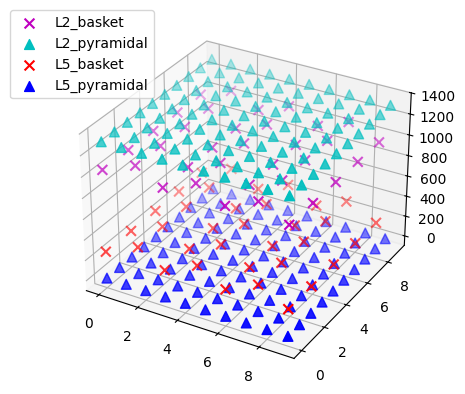

In [11]:
# we can plot a diagram of the network using the .plot_cells() method
_ = net_default.plot_cells()

The `hnn_core.cell.Cell` class also contains its own set of methods and data attributes. For example, we can plot the morphology of the "L5_pyramidal" cell using the `.plot_morphology()` method

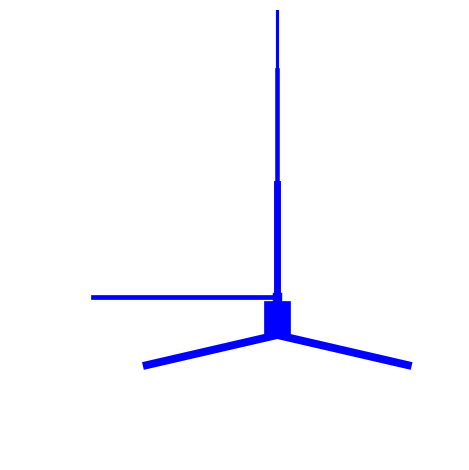

In [12]:
# using the variable we created above, we can access the `Cell` class
# object and plot its morphology

# remember: l5_pyr_celltype is a dictionary, so we need to use the
# "cell_object" key to access the `Cell` class for plotting

_ = l5_pyr_celltype["cell_object"].plot_morphology()

## Simulate the Default Network

Let's begin by importing all of the dependencies we will need for this section of the tutorial

In [13]:
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from hnn_core import (
    JoblibBackend,
    MPIBackend,
    read_dipole,
    simulate_dipole,
)
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.viz import plot_dipole

### Load Experimental Data

Following the typical experimental workflow outlined in the [Simulation Workflow](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_simulation_workflow.html) page, we will begin by importing some real experimental MEG data.

As a reminder, the data we use in these tutorials are from the Jones et al. 2007 study, as detailed in the [Introduction and ERP Overview](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html) page. 

Using the code below, we can fetch the data for the treshold-level tacile evoked response directly from our lab's `hnn-data` GitHub repository. (If you prefer, you can also clone the `hnn-data` repository to your local machine and import the data from there)

In [ ]:
# link to the data in the `hnn-data` GitHub repository
data_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/MEG_detection_data/yes_trial_S1_ERP_all_avg.txt"
urlretrieve(
    data_url,
    "yes_trial_S1_ERP_all_avg.txt",
)

('yes_trial_S1_ERP_all_avg.txt', <http.client.HTTPMessage at 0x10bdba330>)

Once we've fetched the data, we can load it with the `read_dipole()` function and assign it to a variable; in this case, we assign it to the variable named `threshold_experimental_dpl`. This process will load the experimental data as a `Dipole` object that can be used with `hnn-core`. 

The `Dipole` object has various attributes that we will not explore in detail at this time. For now, we will focus on two specific data attributes: `times` and `data`. 

Let's examine these attributes in more detail.

In [15]:
# load the experimental data as a `Dipole` object and
# assign it to a variable
threshold_experimental_dpl = read_dipole(
    "yes_trial_S1_ERP_all_avg.txt",
)

# assign the `times` data attribute to a variable
threshold_times = threshold_experimental_dpl.times

# assign the `data` data attribute to a variable
threshold_data = threshold_experimental_dpl.data

print(
    f"Object type: {type(threshold_experimental_dpl)}",
    f"  Data type: {type(threshold_data)}",
    f" Times type: {type(threshold_times)}",
    sep="\n",
)

Object type: <class 'hnn_core.dipole.Dipole'>
  Data type: <class 'dict'>
 Times type: <class 'numpy.ndarray'>


We can see that the `data` attribute is a dictionary, while the `times` attribute is an array. As the names imply, the current dipole data are stored in the `data` dictionary, while the timesteps are stored directly in the `times` attribute.  

Let's examine the `data` dictionary in more detail, printing its keys and value types.

In [16]:
print("Examining the `data` dictionary:")

for key, value in threshold_data.items():
    print(f'   Key: "{key}"\n      Value type: {type(value)}')

Examining the `data` dictionary:
   Key: "agg"
      Value type: <class 'numpy.ndarray'>


We can see that the `data` dictionary has a single key named `agg` that points to an array.

Since the source data `yes_trial_S1_ERP_all_avg.txt` has two columns (you can verify this by pasting the URL above in your browser and examining the data), the `read_dipole()` function assumes that one column represents the times (in miliseconds), and the other represents the aggregate current dipole (in nano-ampere meters, nAm). 

Therefore, the `agg` key in our `data` dictionary refers to the aggregate current dipole.

If our source data had four columns, `read_dipole()` would assume that the columns correspond to:
  1) times (ms)
  2) aggregate current dipole (nAm)
  3) L2/3 current dipole (nAm)
  4) L5 current dipole (nAm)

In the above case, the `data` dictionary would contain additional keys for the L2/3 and L5 current dipoles.

Now that we've explored the loaded data objects, let's go ahead and use the built-in `Dipole.plot()` method to view the data

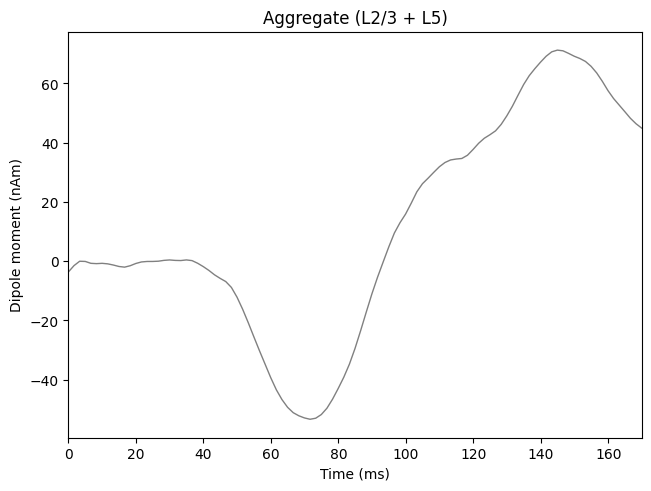

In [17]:
_ = threshold_experimental_dpl.plot()

You can see that the built-in plot method is assuming that the units of time are in miliseconds, and that the units of the current dipole are in nAm. The data plotted are for the Aggregate dipole, which is the sum of the Layer 2/3 and Layer 5 dipoles. 

### Prepare the Default Network for Simulation

Remember that exogenous inputs (modelled as spike trains arriving at the proximal or distal locations in the network) are necessary to drive network activity.

However, the `jones_2009_model()` does not have external driving inputs by default. We can verify this by confirming the `external drives` data attribute is empty

In [18]:
print("Check if the `jones_2009_model` includes external drives ...")
if jones_2009_model().external_drives:
    print("   Existing drives found!")
else:
    print("   No drives found; `jones_2009_model().external_drives` is empty")

Check if the `jones_2009_model` includes external drives ...
   No drives found; `jones_2009_model().external_drives` is empty


We can add the default drives for simulating ERPs automatically using the `add_erp_drives_to_jones_model()` function we imported from `hnn_core.network_models`. (You can also manually add individual drives, and we will cover how to do so in a future section.)

Let's first check if there are an external drives already attached to our network object `net default`; if not, we'll add the drives using the aforementioned function. 

Lastly, we will inspect the drives attached to `net_default`. For simulating ERPs, we expect to see two proximal drives and one distal drive.  


In [19]:
# if there are no drives attached to the Network, then add them
if not net_default.external_drives:
    print("\nNo existing drives found. Adding default external drives ... ")

    # add the default external drives for ERP simulation
    # note:
    #   the drives are added to the object **in place**, meaning we don't
    #   need to assign the output back to the `net_default` variable
    add_erp_drives_to_jones_model(net_default)

    print("The following drives were added:")
else:
    print("\nExisting drives found on the network object.")
    print("\nPrinting existing drive names:")

for key in net_default.external_drives.keys():
    print(f"   {key}")


No existing drives found. Adding default external drives ... 
The following drives were added:
   evdist1
   evprox1
   evprox2


Next, let's check the arrival time of each drive. Remember that for ERPs, we expect an initial feedforward (proximal) input, followed by a feedback (distal) input, followed by a second feedforward (proximal) input. 

As discussed in the [Introduction and ERP Overview](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html) page, this sequence of driving inputs was based on studying evoked potentials in animals using invasive recordings, and served as our starting point simulating human ERPs with HNN. 

To get the mean arrival times, we will need to access a nested attribute of each `_NetworkDrive` object. Specifically, we will print the value of the `"mu"` parameter in the `"dynamics"` dictionary. Note that each `_NetworkDrive` object itself acts like a dictionary, and `"dynamics"` is one of the keys of that dictionary

In [ ]:
# ----------------------------------------
# inspecting a single drive object
# ----------------------------------------
# let's first inspect a single external drive object to understand
# its structure

# we can create a pointer to the "evdist1" object like so
key = "evdist1"
drive_object = net_default.external_drives[key]

# as mentioned above, we'll be accessing the value of the "mu"
# parameter in the "dynamics" dictionary.

# we can create pointers to these objects to make the printouts
# below more readable
drive_dynamics = drive_object["dynamics"]
mean_arrival = drive_dynamics["mu"]

print(
    "# Examining one drive object in detail",
    "\n# " + "-" * 40 + "\n",
    sep="",
)

print(
    "Examining the `_NetworkDrive` object",
    f"    Drive type: {type(drive_object)}",
    f"    Drive name: {drive_object['name']}",
    f"    Drive keys:\n\t {str(list(drive_object.keys()))}",
    "",
    f'Examining ["dynamics"] for the "{key}" `_NetworkDrive` object',
    f"    Type: {type(drive_dynamics)}",
    f"    Keys:\n\t{list(drive_dynamics.keys())}",
    "",
    sep="\n",
)

# ----------------------------------------
# printing "mu" for each drive
# ----------------------------------------

# now let's loop through each drive and print the
# value of "mu" (i.e., the mean arrival time)

print(
    '# Print each drive\'s "mu" parameter',
    "\n# " + "-" * 40 + "\n",
    sep="",
)

for key, drive_object in net_default.external_drives.items():
    mean_arrival = drive_object["dynamics"]["mu"]

    print(
        f'Mean arrival time for "{key}": {mean_arrival} ms',
        sep="\n",
    )

# Examining one drive object in detail
# ----------------------------------------

Examining the `_NetworkDrive` object
    Drive type: <class 'hnn_core.network._NetworkDrive'>
    Drive name: evdist1
    Drive keys:
	 ['type', 'location', 'n_drive_cells', 'event_seed', 'conn_seed', 'dynamics', 'events', 'weights_ampa', 'weights_nmda', 'synaptic_delays', 'probability', 'name', 'target_types', 'cell_specific']

Examining ["dynamics"] for the "evdist1" `_NetworkDrive` object
    Type: <class 'dict'>
    Keys:
	['mu', 'sigma', 'numspikes']

# Print each drive's "mu" parameter
# ----------------------------------------

Mean arrival time for "evdist1": 63.53 ms
Mean arrival time for "evprox1": 26.61 ms
Mean arrival time for "evprox2": 137.12 ms


We can see that the drives we added do follow the expected sequence: a proximal drive arriving first at ~27 ms, a distal drive arriving second at ~64 ms, and a second proximal drive arriving last at ~ 137 ms.

Now that we've added the external drives to the `Network`, we are nearly ready to run our simulation of the threshold-level ERP.

### Run the Default Simulation

Before running the simulation, we need to choose a backend. HNN-core supports both the Joblib backend (which can run independent simulation trials in parallel), and the MPI backend (which can distribute the computation of a single simulation trial across multiple processes)

You can try running the simulation with both Joblib and MPI and compare the simulation speeds by changing the `use_MPI` flag below from False to True, or vice versa

Additionally, you should set the number of cores to use based on your machine's resources. There are instructions on how to check the number of available cores on the [Installation](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) page. 

In [21]:
# choose a backend, and select the number of cores
# --------------------------------------------------
# try changing the use_MPI flag and comparing
# the simulation speeds
use_MPI = True

if use_MPI is False:
    chosen_backend = JoblibBackend
else:
    chosen_backend = MPIBackend

# when calling our `chosen_backend` below, we can
# explicitly set the number of cores to use
#
# in general, more cores = faster simulations
ncores = 4

The `simulate_dipole()` function below is the main function for generating simulated dipole signals from a `Network` object. It has two required arguments:
  1. the `Network` object
  2. the simulation duration (specified in ms)

The function accepts additional simulation parameters, including the integration timestep, the number of trials, and more

Once we've selected a backend, set the number of cores, and specified our required (and optional) simulation parameters, we're finally ready to run the default simulation for the threshold-level ERP

Note the syntax used to simulate the `Network` below. We use a `with` statement to run the simulation using the selected parallel backend (stored in `chosen_backend` in this case). The `simulate_dipole()` function is called inside this block, and the resulting output is assigned to the variable `dipoles_list`.

When we run the simulation below, `hnn-core` computes the cell and circuit activity, calculates the current dipoles, and returns a list of `Dipole` objects (one per each trial).


In [ ]:
# set additional simulation parameters
tstop = 170.0  # length of the simulation
dt = 0.05  # integration timestep
n_trials = 1  # number of trials

# run the simulation
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_default,
        tstop=tstop,
        n_trials=n_trials,
        dt=dt,
    )

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
numprocs=4
Loading custom mechanism files from /opt/homebrew/Caskroom/miniconda/base/envs/textbook-dev-build/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/homebrew/Caskroom/miniconda/base/envs/textbook-dev-build/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/homebrew/Caskroom/miniconda/base/envs/textbook-dev-build/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/homebrew/Caskroom/miniconda/base/envs/textbook-dev-build/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
[Done]
Trial 1: 0.05 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial

### Plot Default Simulation with Data

The simulation we just ran yields a dipole signal in units of nanoampere-meters (nAm). Remember that source-localize MEG and EEG data yield dipole signals in these same units of nAm. By representing the simulation and the experimental data in the same units, HNN enables a one-to-one comparison between the two signals.

Next, let's plot the experimental data alongside the simulated dipole output and compare the two signals directly.

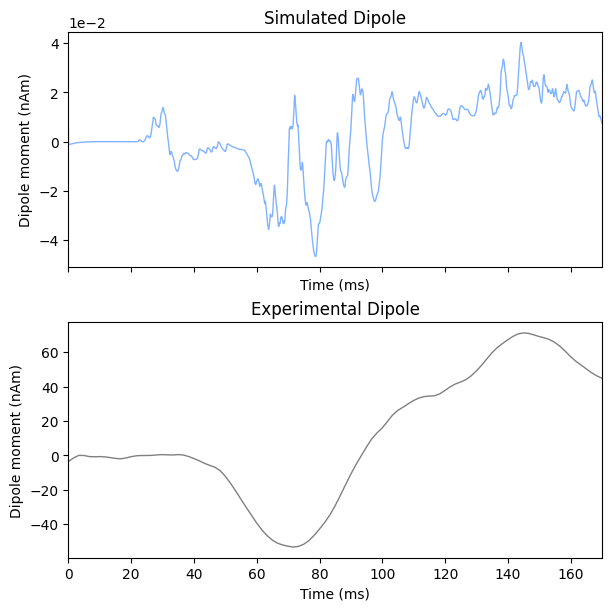

In [160]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6, 6),
    constrained_layout=True,
)

_ = plot_dipole(
    dipoles_list,
    ax=axes[0],
    layer="agg",
    color="#0066FF",
    show=False,
)

_ = threshold_experimental_dpl.plot(
    ax=axes[1],
    show=False,
)

axes[0].set_title("Simulated Dipole")
axes[1].set_title("Experimental Dipole");


You should note that the simulated dipole signal and the loaded data look quite different in both their shapes and their magnitudes. 

These discrepancies are due to the fact that `simulate_dipole()` returns a list of **raw** dipole signals. There are some post-processing steps we need to follow before we can truly compare our simulated and experimental dipoles, and we will discuss these steps in the next section. 

## Simulation Scaling and Smoothing in the API

Since we'll be plotting multiple figures in this section, let's define a color dictionary so that we can reuse colors without needing to manually specify the hexicecimal code every time we plot something. We'll try to use colors that mimic what is used in the HNN GUI video (above), though note that the GUI is more restrictive than the API and so there will be some discrepancies. 

In [220]:
gui_colors = {
    "orange": "#ff7f0e",
    "blue": "#1f77b4"
}

In the previous section, we ended with a plot of the raw simulated dipole and the loaded experimental dipole, which were different in both their shapes and magnitudes. 

These discrepancies are related to **Step 3** of our experimental workflow:

  1. **Adjust the scaling (and smoothing) of your simulated dipole signal**

With HNN, we simulate a network comprised of two 10 x 10 grids of pyramidal neurons, in two distinct cortical layers, for a total of 200 pyramidal neurons that contribute directly to the simulated dipole signal. (There are also 35 interneurons per layer, but these do not contribute *directly* to the dipole signal.) 

The human cortex, however, contains *many* more pyramidal neurons than in our reduced network, and source-localized MEG signals typically represent the synchronous activity of tens of thousands of pyramidal neurons.

Rather than explicitly simulate thousands of neurons, we can leverage the fact that the neocortex has a highly stereotyped, canonical circuit architecture. As such, the activity generated by a relatively small cortical column can be viewed as representative of the *synchronous* activity in a larger patch of cortex, and it is precisely this synchronous activity that we observe in our source-localized, experimental ERP data.

In the model, we represent this synchrony by multiplying our simulated dipole signal by a **uniform scaling factor**, which effectively captures the synchronous activity of a larger population of similarly-active neurons

We do this in `hnn-core` by using the `.scale()` method of the `Dipole` object.

Remember that the `simulate_dipole()` function returns a list of dipole objects, one for each trial. We need to first select an individual trial to apply the dipole scaling factor. 

In [41]:
# get the first (in this case, only) trial from the
# list of dipole objects
dipole_01 = dipoles_list[0]

Keep in mind that the scaling factor is applies to the object **in place** (in otherwords, the new dipole with the scaling applied will "overwrite" the raw, unscaled dipole)

Let's make a copy of the dipole object before we apply the scaling factor so we can plot both dipoles

In [45]:
# we use copy() to ensure we have a new copy of the dipole
# that is seprate from the original
dipole_01_scaled = dipole_01.copy()

# set scaling factor and apply it to the copy only
scaling_factor = 3000
dipole_01_scaled.scale(scaling_factor);

Note that we multiply the simulated dipole by a **uniform** scaling factor at each time point such that we are not altering the underlying shape of the signal, *only* the magnitude of the peaks and troughs. This ensure we are not overfitting to the experimental data, as fitting the scaling factor to any one peak *necessarily* changes the value every other time point.

We can see that this is the case when plotting the unscaled and scaled dipoles side by side. Note that the y axes are different, but the underlying waveform shapes (relative peaks and troughs) remain the same

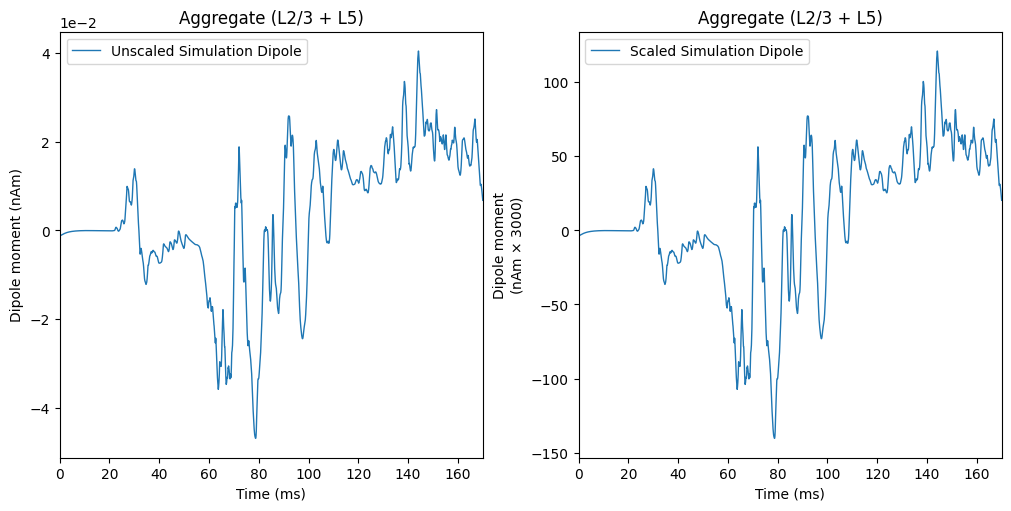

In [223]:
# plot the dipoles side by side
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True,
)

_ = dipole_01.plot(
    ax=axes[0],
    show=False,
)
_ = dipole_01_scaled.plot(
    ax=axes[1],
    show=False,
)

# style subplots
# --------------------------------------------------
axes[0].lines[0].set_color(gui_colors["blue"])
axes[0].lines[0].set_label("Unscaled Simulation Dipole")
axes[0].legend()

axes[1].lines[0].set_color(gui_colors["blue"])
axes[1].lines[0].set_label("Scaled Simulation Dipole")
axes[1].legend();

We can add the experimental data to these plots to compare the order of magnitude and see if our scaling factor was appropriate 

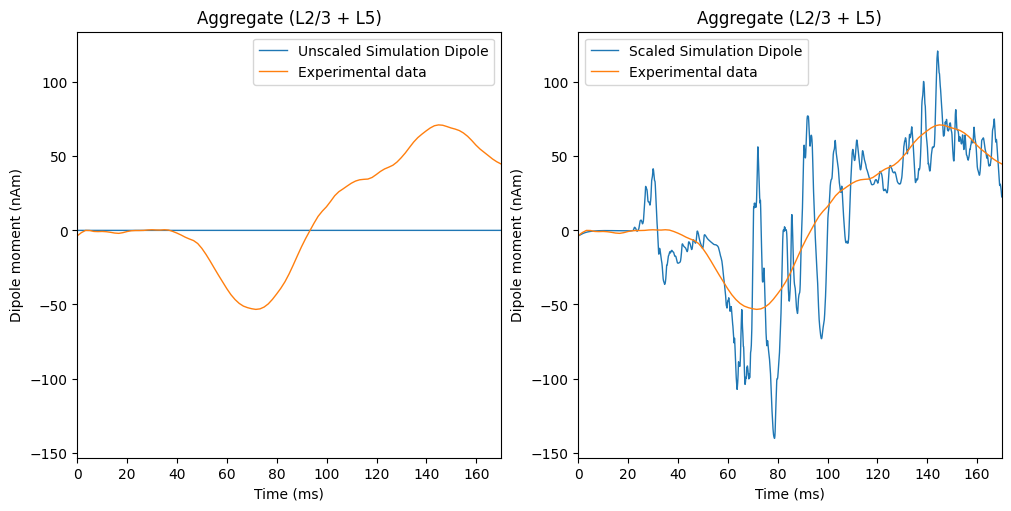

In [ ]:
# check if the experimental data needs to be added
# by looking at the number of lines on a subplot
# --------------------------------------------------
if len(axes[0].lines) == 1:
    _ = threshold_experimental_dpl.plot(
        ax=axes[0],
        color="black"
    )

    _ = threshold_experimental_dpl.plot(
        ax=axes[1],
        color="black"
    )

# ensure y axes are equal across subplots
# --------------------------------------------------
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)

axes[0].set_ylim(ymin=ymin, ymax=ymax)
axes[1].set_ylim(ymin=ymin, ymax=ymax)

# style subplots
# --------------------------------------------------
axes[0].lines[1].set_color(gui_colors["orange"])
axes[0].lines[1].set_label("Experimental data")
axes[0].legend()

axes[1].lines[1].set_color(gui_colors["orange"])
axes[1].lines[1].set_label("Experimental data")
axes[1].legend()

fig

While the scaled simulation dipole is much closer to the order of magnitude of the experimental dipole, the signals themselves still differ substantially in their waveform shapes. 

This is because source-localized signals reflect the aggregate activity of a very large population of neurons. When a large number of neurons contribute synchronously to the measured signal, small differences in their individual spike timing tend to be averaged out, producing a "smoother" dipole signal than we obtain from our smaller simulated network.

To approximate this effect, we can use the `.smooth()` method of the `Dipole` object, which applies a Hamming-windowed convolution to the simulated dipole. The width of this convolution window is specified in milliseconds, allowing you to control the amount of smoothing applied to the signal.

Note that the `.smooth()` method also updates the dipole *in place*, so we will first make a copy of the object before the transformation. Below, we will plot updated dipoles using two different window widths for comparison.

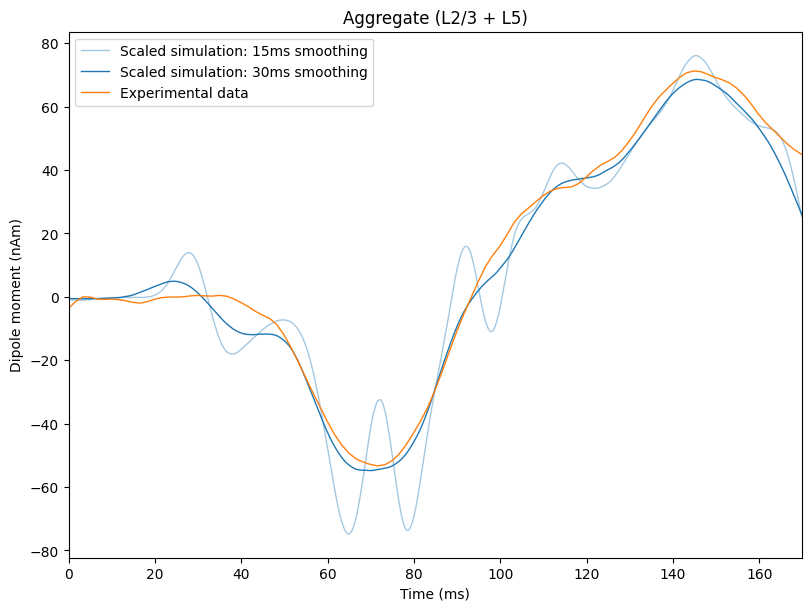

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 6),
    constrained_layout=True,
)

# plot scaled dipole with 15ms window
# --------------------------------------------------
dipole_15ms = dipole_01_scaled.copy().smooth(15)

_ = plot_dipole(
    dipole_15ms,
    ax=ax,
    show=False,
)

# pro tip: "[-1]" here targets the newly-added line
ax.lines[-1].set_color(gui_colors["blue"])
ax.lines[-1].set_alpha(0.4)  # reduce the opacity to 40%
ax.lines[-1].set_label("Scaled simulation: 15ms smoothing")

# plot scaled dipole with 30ms window
# --------------------------------------------------
dipole_30ms = dipole_01_scaled.copy().smooth(30)

_ = plot_dipole(
    dipole_30ms,
    ax=ax,
    show=False,
)

ax.lines[-1].set_color(gui_colors["blue"])
ax.lines[-1].set_label("Scaled simulation: 30ms smoothing")

# plot experimental data
# --------------------------------------------------
_ = threshold_experimental_dpl.plot(
    ax=ax,
    show=False,
)

ax.lines[-1].set_label("Experimental data")
ax.lines[-1].set_color(gui_colors["orange"])

plt.legend();

We can see that the fit is considerably improved after applying the smoothing to the simulation. 

Lastly, it is important to note that the scaling factor also gives us an estimate of the number of synchronous neurons that contributed to our experimental dipole signal.

For example, if the M70 peak in our our experimental data is approximately -60 nAm, and the raw simulated dipole signal is approximately -0.02 nAm, then we would need to multiply the simulated dipole by 3,000 to bring the signals into the same order of magnitude. In this case, we would estimate that approximately 3,000 x 200 = 600,000 pyramidal neurons are contributing to the signal in the *experimental* data. 

While we've found that a scaling factor of 3,000 and a smoothing window of 30 work well for the experimental MEG data in Jones et al. 2007, there is no guarantee that these will be appropriate for your experimental data. In fact, it is very likely that you will need to try different scaling factors and smoothing windows to bring your simulation and your data into the same order of magnitude. 

## 4.7